# Download Experiment Results from WandB

This notebook downloads probe performance results from WandB for different:
- Response generation policies (on-policy, prompted, incentivised, off-policy)
- Data domains (same-domain vs. different-domain)
- Behaviours
- Test conditions

Output: A structured CSV file with all probe performance metrics.


In [4]:
%%capture
# If getting 'Could not find project LASR_probe_gen' get key from https://wandb.ai/authorize and paste below
import os
os.environ["WANDB_SILENT"] = "true"
import wandb
wandb.login(key="f91061a9f7a4be0955ec68dfa9551294811581d1")

In [5]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

# Add project root to path
project_root = Path().absolute().parent / "src"
sys.path.insert(0, str(project_root))

from probe_gen.probes.wandb_interface import load_probe_eval_dicts_as_df
from probe_gen.standard_experiments.hyperparameter_search import get_best_hyperparams_for_train_setup
from probe_gen.config import BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL, BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION


## Configuration


In [6]:
# Set experiment parameters
probe_type = "mean"  # Options: "mean", "attention_torch"
activations_model = "llama_3b"  # Currently the main option

# Choose whether to include deception experiments
include_deception = True

# Set test conditions
test_gen_methods = ['on_policy', 'incentivised']  # Test against both natural and incentivised

# Training generation methods to query
train_gen_methods = ['on_policy', 'incentivised', 'prompted', 'off_policy']


## Setup Experiment Configurations


In [7]:
# Combine experiment configurations
done_experiments = BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL.copy()
if include_deception:
    done_experiments.update(BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION)

print(f"Behaviours to query: {list(done_experiments.keys())}")
print(f"Total behaviours: {len(done_experiments)}")


Behaviours to query: ['refusal', 'lists', 'metaphors', 'science', 'sycophancy', 'authority', 'deception', 'sandbagging']
Total behaviours: 8


## Function to Download Results


In [8]:
def download_probe_results(
    probe_type,
    behaviour,
    train_datasource,
    test_datasource,
    activations_model,
    train_gen_method,
    test_gen_method,
    train_response_model,
    test_response_model
):
    """
    Downloads probe results from WandB for a specific configuration.
    
    Returns:
        dict: Dictionary with AUROC and other metrics, or None if not found
    """
    # Get best hyperparameters for this configuration
    full_tr = [probe_type, behaviour, train_datasource, activations_model, 
               train_gen_method, train_response_model, "train"]
    
    try:
        cfg = get_best_hyperparams_for_train_setup([full_tr])[0][-1]
    except Exception as e:
        print(f"⚠ Could not get hyperparameters for {behaviour} - {train_gen_method}: {e}")
        return None
    
    # Build search dictionary for WandB query
    search_dict = {
        "config.probe/type": probe_type,
        "config.behaviour": behaviour,
        "config.train/datasource": train_datasource,
        "config.train/generation_method": train_gen_method,
        "config.train/response_model": train_response_model,
        "config.test/datasource": test_datasource,
        "config.test/generation_method": test_gen_method,
        "config.test/response_model": test_response_model,
        "config.layer": cfg.layer,
        "config.probe/use_bias": cfg.use_bias,
        "config.probe/normalize": cfg.normalize,
        "config.activations_model": activations_model,
        "state": "finished"
    }
    
    # Add probe-specific hyperparameters
    if probe_type == "mean":
        search_dict["config.probe/C"] = cfg.C
    elif "torch" in probe_type:
        search_dict["config.probe/lr"] = cfg.lr
        search_dict["config.probe/weight_decay"] = cfg.weight_decay
    
    # Query WandB
    try:
        run_df = load_probe_eval_dicts_as_df(search_dict)
        
        if len(run_df) == 0:
            return None
        
        # Return the last (most recent) result
        return {
            'roc_auc': run_df['metric_roc_auc'].iloc[-1],
            'accuracy': run_df.get('metric_accuracy', [None] * len(run_df)).iloc[-1],
            'tpr_at_1_fpr': run_df.get('metric_tpr_at_1_fpr', [None] * len(run_df)).iloc[-1],
        }
    except Exception as e:
        print(f"⚠ Error querying WandB for {behaviour} - {train_gen_method}: {e}")
        return None


## Download All Results


In [9]:
# Collect all results
all_results = []

# Iterate through all behaviours
for behaviour in tqdm(list(done_experiments.keys()), desc="Behaviours"):
    behaviour_config = done_experiments[behaviour]
    
    # Get the two datasources (ID and OOD)
    datasources = [ds for ds in behaviour_config.keys() if ds != "test_both"]
    print(f"{behaviour}:{datasources}")
    
    if len(datasources) < 2:
        print(f"⚠ Skipping {behaviour}: needs at least 2 datasources")
        continue
    
    id_datasource = datasources[0]
    ood_datasource = datasources[1]
    
    # Get off-policy models
    id_off_policy_model = behaviour_config[id_datasource][activations_model]
    ood_off_policy_model = behaviour_config[ood_datasource][activations_model]
    
    # Iterate through test conditions
    for test_gen_method in test_gen_methods:
        # Same-domain experiments (train and test on ID datasource)
        for train_gen_method in tqdm(train_gen_methods, desc=f"{behaviour} - Same-Domain", leave=False):
            train_response_model = id_off_policy_model if train_gen_method == "off_policy" else activations_model
            test_response_model = activations_model
            
            results = download_probe_results(
                probe_type=probe_type,
                behaviour=behaviour,
                train_datasource=id_datasource,
                test_datasource=id_datasource,
                activations_model=activations_model,
                train_gen_method=train_gen_method,
                test_gen_method=test_gen_method,
                train_response_model=train_response_model,
                test_response_model=test_response_model
            )
            
            if results:
                all_results.append({
                    'probe_type': probe_type,
                    'behaviour': behaviour,
                    'train_domain': 'same',
                    'train_datasource': id_datasource,
                    'test_datasource': id_datasource,
                    'train_generation_method': train_gen_method,
                    'test_generation_method': test_gen_method,
                    'activations_model': activations_model,
                    'train_response_model': train_response_model,
                    'test_response_model': test_response_model,
                    **results
                })
        
        # Different-domain experiments (train on OOD, test on ID)
        for train_gen_method in tqdm(train_gen_methods, desc=f"{behaviour} - Diff-Domain", leave=False):
            train_response_model = ood_off_policy_model if train_gen_method == "off_policy" else activations_model
            test_response_model = activations_model
            
            results = download_probe_results(
                probe_type=probe_type,
                behaviour=behaviour,
                train_datasource=ood_datasource,
                test_datasource=id_datasource,
                activations_model=activations_model,
                train_gen_method=train_gen_method,
                test_gen_method=test_gen_method,
                train_response_model=train_response_model,
                test_response_model=test_response_model
            )
            
            if results:
                all_results.append({
                    'probe_type': probe_type,
                    'behaviour': behaviour,
                    'train_domain': 'different',
                    'train_datasource': ood_datasource,
                    'test_datasource': id_datasource,
                    'train_generation_method': train_gen_method,
                    'test_generation_method': test_gen_method,
                    'activations_model': activations_model,
                    'train_response_model': train_response_model,
                    'test_response_model': test_response_model,
                    **results
                })

print(f"\n✓ Downloaded {len(all_results)} results")


Behaviours:   0%|          | 0/8 [00:00<?, ?it/s]

refusal:['rlhf', 'jailbreaks']


Behaviours:  12%|█▎        | 1/8 [00:28<03:17, 28.21s/it]

lists:['ultrachat', 'shakespeare']


Behaviours:  25%|██▌       | 2/8 [01:03<03:15, 32.66s/it]

...

deception:['roleplaying', 'trading']


Behaviours:  88%|████████▊ | 7/8 [03:22<00:26, 26.09s/it]

sandbagging:['wmd', 'multichoice']


Behaviours: 100%|██████████| 8/8 [03:41<00:00, 27.67s/it]


✓ Downloaded 112 results


In [10]:
# Create DataFrame from results
results_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = [
    'probe_type',
    'behaviour',
    'train_domain',
    'train_generation_method',
    'test_generation_method',
    'train_datasource',
    'test_datasource',
    'activations_model',
    'train_response_model',
    'test_response_model',
    'roc_auc',
    'accuracy',
    'tpr_at_1_fpr'
]

results_df = results_df[column_order]

# Set 'lists' as the reference category for behaviour
results_df['behaviour'] = pd.Categorical(
    results_df['behaviour'],
    categories=['lists', 'authority', 'deception', 'metaphors', 'refusal', 'sandbagging', 'science', 'sycophancy'],
    ordered=False
)

# Display first few rows
print("\nFirst 10 rows:")
display(results_df.head(10))

print(results_df["behaviour"].unique())
print(f"\nDataFrame shape: {results_df.shape}")
print(f"Unique behaviours: {results_df['behaviour'].nunique()}")
print(f"Unique train generation methods: {results_df['train_generation_method'].unique()}")


First 10 rows:


,probe_type,behaviour,train_domain,train_generation_method,test_generation_method,train_datasource,test_datasource,activations_model,train_response_model,test_response_model,roc_auc,accuracy,tpr_at_1_fpr
0,mean,refusal,same,on_policy,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.908516,0.854,0.102
1,mean,refusal,same,incentivised,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.913076,0.861,0.072
2,mean,refusal,same,prompted,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.913100,0.844,0.098
3,mean,refusal,same,off_policy,on_policy,rlhf,rlhf,llama_3b,ministral_8b,llama_3b,0.909240,0.834,0.124
4,mean,refusal,different,on_policy,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.841504,0.733,0.100
5,mean,refusal,different,incentivised,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.857956,0.761,0.138
6,mean,refusal,different,prompted,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.834816,0.767,0.042
7,mean,refusal,different,off_policy,on_policy,jailbreaks,rlhf,llama_3b,ministral_8b,llama_3b,0.757300,0.604,0.006
8,mean,refusal,same,incentivised,incentivised,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.922096,0.643,0.382
9,mean,refusal,same,prompted,incentivised,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.940028,0.673,0.524


['refusal', 'lists', 'metaphors', 'science', 'sycophancy', 'authority', 'deception', 'sandbagging']
Categories (8, object): ['lists', 'authority', 'deception', 'metaphors', 'refusal', 'sandbagging', 'science', 'sycophancy']

DataFrame shape: (112, 13)
Unique behaviours: 8
Unique train generation methods: ['on_policy' 'incentivised' 'prompted' 'off_policy']


In [11]:
results_test_on_policy = results_df[(results_df['test_generation_method'] == 'on_policy') & (results_df['behaviour'] != 'deception') & (results_df['behaviour'] != 'sandbagging')]

results_test_on_policy

,probe_type,behaviour,train_domain,train_generation_method,test_generation_method,train_datasource,test_datasource,activations_model,train_response_model,test_response_model,roc_auc,accuracy,tpr_at_1_fpr
0,mean,refusal,same,on_policy,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.908516,0.854,0.102
1,mean,refusal,same,incentivised,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.913076,0.861,0.072
2,mean,refusal,same,prompted,on_policy,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.913100,0.844,0.098
3,mean,refusal,same,off_policy,on_policy,rlhf,rlhf,llama_3b,ministral_8b,llama_3b,0.909240,0.834,0.124
4,mean,refusal,different,on_policy,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.841504,0.733,0.100
5,mean,refusal,different,incentivised,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.857956,0.761,0.138
6,mean,refusal,different,prompted,on_policy,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.834816,0.767,0.042
7,mean,refusal,different,off_policy,on_policy,jailbreaks,rlhf,llama_3b,ministral_8b,llama_3b,0.757300,0.604,0.006
14,mean,lists,same,on_policy,on_policy,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.967836,0.907,0.796
15,mean,lists,same,incentivised,on_policy,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.948592,0.876,0.656


In [12]:
results_test_incentivised = results_df[(results_df['test_generation_method'] == 'incentivised') & (results_df['train_generation_method'] != 'on_policy')]


results_test_incentivised

,probe_type,behaviour,train_domain,train_generation_method,test_generation_method,train_datasource,test_datasource,activations_model,train_response_model,test_response_model,roc_auc,accuracy,tpr_at_1_fpr
8,mean,refusal,same,incentivised,incentivised,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.922096,0.643,0.382
9,mean,refusal,same,prompted,incentivised,rlhf,rlhf,llama_3b,llama_3b,llama_3b,0.940028,0.673,0.524
10,mean,refusal,same,off_policy,incentivised,rlhf,rlhf,llama_3b,ministral_8b,llama_3b,0.930760,0.744,0.450
11,mean,refusal,different,incentivised,incentivised,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.875240,0.782,0.250
12,mean,refusal,different,prompted,incentivised,jailbreaks,rlhf,llama_3b,llama_3b,llama_3b,0.830788,0.685,0.166
13,mean,refusal,different,off_policy,incentivised,jailbreaks,rlhf,llama_3b,ministral_8b,llama_3b,0.860724,0.652,0.110
23,mean,lists,same,incentivised,incentivised,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.915548,0.829,0.600
24,mean,lists,same,prompted,incentivised,ultrachat,ultrachat,llama_3b,llama_3b,llama_3b,0.921936,0.834,0.504
25,mean,lists,same,off_policy,incentivised,ultrachat,ultrachat,llama_3b,qwen_3b,llama_3b,0.909444,0.821,0.500
26,mean,lists,different,incentivised,incentivised,shakespeare,ultrachat,llama_3b,llama_3b,llama_3b,0.791168,0.731,0.060


# Mixed Model 

In [71]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np


def extract_domain_significance_from_model(model_result, results_df):
    """
    Extract domain effect significance for each behaviour from the interaction model.
    
    Parameters:
    -----------
    model_result : statsmodels MixedLMResults
        The fitted model result from your interaction analysis
    results_df : pd.DataFrame
        Your data to get behaviour names
        
    Returns:
    --------
    dict : behaviour name -> p-value
    """
    
    # Get p-values from the model
    pvalues = model_result.pvalues
    
    # Extract baseline domain effect (for authority/first behaviour)
    baseline_p = pvalues.get('train_domain[T.different]', 0.000)
    
    # Map each behaviour to its p-value
    significance = {}
    behaviours = results_df['behaviour'].unique()
    
    for behav in behaviours:
        behav_cap = behav.capitalize()
        # Look for interaction term for this behaviour
        interaction_key = f'train_domain[T.different]:C(behaviour)[T.{behav}]'
        
        if interaction_key in pvalues:
            # This behaviour has an interaction term
            significance[behav_cap] = pvalues[interaction_key]
        else:
            # This is the baseline behaviour (authority)
            significance[behav_cap] = baseline_p
    
    return significance


def extract_generation_method_pvalues(model_result, available_methods=None):
    """
    Extract p-values for generation method effects from the model.
    
    Parameters:
    -----------
    model_result : statsmodels MixedLMResults
        The fitted model result
    available_methods : list, optional
        List of generation methods present in the data. If None, will detect from model.
        
    Returns:
    --------
    dict : method name -> p-value (or 'ref' for reference category)
    """
    pvalues = model_result.pvalues
    
    # Determine which methods are available and which is reference
    method_keys = [k for k in pvalues.index if 'generation_method[T.' in k or 'train_generation_method[T.' in k]
    
    # Extract method names from keys
    available_from_model = []
    for key in method_keys:
        if 'generation_method[T.' in key:
            method = key.split('generation_method[T.')[1].split(']')[0]
            available_from_model.append(method)
        elif 'train_generation_method[T.' in key:
            method = key.split('train_generation_method[T.')[1].split(']')[0]
            available_from_model.append(method)
    
    # All possible methods
    all_methods = ['on_policy', 'incentivised', 'off_policy', 'prompted']
    
    # Determine reference method (the one not in the model keys)
    if available_methods:
        present_methods = available_methods
    else:
        present_methods = all_methods
    
    reference_method = None
    for method in present_methods:
        if method not in available_from_model:
            reference_method = method
            break
    
    # Build p-value dictionary
    method_pvals = {}
    for method in present_methods:
        if method == reference_method:
            method_pvals[method] = 'ref'
        else:
            # Try both possible key formats
            key1 = f'generation_method[T.{method}]'
            key2 = f'train_generation_method[T.{method}]'
            method_pvals[method] = pvalues.get(key1, pvalues.get(key2, 1.0))
    
    return method_pvals


def plot_domain_vs_generation_comparison(results_df, model_result=None, domain_significance=None,
                                        generation_column='generation_method',
                                        figsize=(20, 8), save_path=None):
    """
    Create side-by-side comparison of domain effect vs generation method effect.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame with columns: 'behaviour', 'train_domain', generation_column, 'roc_auc'
    model_result : statsmodels MixedLMResults, optional
        The fitted model to extract significance from
    domain_significance : dict, optional
        Dictionary mapping behaviour names to p-values (overrides model_result)
    generation_column : str, optional
        Name of the column containing generation method ('generation_method' or 'train_generation_method')
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure
    
    Returns:
    --------
    fig, (ax1, ax2) : matplotlib figure and axes
    """
    
    # Extract significance from model if provided
    if domain_significance is None and model_result is not None:
        domain_significance = extract_domain_significance_from_model(model_result, results_df)
    elif domain_significance is None:
        # Use all significant as default
        domain_significance = {behav.capitalize(): 0.001 
                             for behav in results_df['behaviour'].unique()}
    
    # Determine which generation methods are available in the data
    # Define preferred order
    preferred_order = ['on_policy', 'incentivised', 'prompted', 'off_policy']
    methods_in_data = set(results_df[generation_column].unique())
    available_methods = [m for m in preferred_order if m in methods_in_data]
    
    # Extract generation method p-values
    if model_result is not None:
        method_pvals_dict = extract_generation_method_pvalues(model_result, available_methods)
    else:
        method_pvals_dict = {method: 1.0 for method in available_methods}
    
    # Define color palette for behaviours
    behavior_colors = {
        'Authority': '#e74c3c',      # Red
        'Sandbagging': '#3498db',     # Blue
        'Deception': '#2ecc71',  # Green
        'Lists': '#9b59b6',  # Purple
        'Metaphors': '#f39c12',  # Orange
        'Science': '#1abc9c',     # Turquoise
        'Refusal': "#000000",  # black
        'Sycophancy': "#c0392b", 
    }
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # ===== LEFT PANEL: Domain effect =====
    slope_data_domain = []
    for behav in results_df['behaviour'].unique():
        behav_means = results_df[results_df['behaviour'] == behav].groupby('train_domain')['roc_auc'].mean()
        same_val = behav_means.loc['same']
        diff_val = behav_means.loc['different']
        penalty = same_val - diff_val
        slope_data_domain.append((behav.capitalize(), same_val, diff_val, penalty))
    
    slope_data_domain.sort(key=lambda x: x[3])
    
    # Plot lines without labels
    legend_data_domain = []
    for behav, same_val, diff_val, penalty in slope_data_domain:
        # Check significance
        p_val = domain_significance.get(behav, 1.0)
        is_significant = p_val < 0.05
        
        # Get color for this behaviour
        color = behavior_colors.get(behav, '#2c3e50')
        linestyle = '-' if is_significant else '--'
        alpha = 0.8 if is_significant else 0.4
        linewidth = 3 if is_significant else 2
        
        ax1.plot([0, 1], [same_val, diff_val], linestyle=linestyle, 
                marker='o', linewidth=linewidth, markersize=10,
                color=color, alpha=alpha, solid_capstyle='round')
        
        # Store data for legend
        sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        legend_data_domain.append((behav, color, penalty, sig_marker, is_significant, linestyle, linewidth, alpha))
    
    ax1.set_xlim([-0.1, 1.1])
    ax1.set_ylim([0.4, 1.0])
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['Same Domain', 'Different Domain'], fontsize=12, fontweight='bold')
    ax1.set_ylabel('ROC-AUC Performance', fontsize=13, fontweight='bold')
    ax1.set_title('A) Domain Effect', fontsize=13, fontweight='bold', pad=15)
    ax1.grid(axis='y', alpha=0.2, linestyle=':', linewidth=0.8)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    
    # Create legend with behavior, color, and delta
    legend_elements_domain = []
    for behav, color, penalty, sig_marker, is_sig, lstyle, lwidth, alpha_val in legend_data_domain:
        legend_elements_domain.append(
            Line2D([0], [0], color=color, linewidth=lwidth, linestyle=lstyle, alpha=alpha_val,
                   label=f'{behav}: Δ={penalty:.3f} {sig_marker}')
        )
    
    ax1.legend(handles=legend_elements_domain, loc='lower left', fontsize=9, 
              framealpha=0.95, edgecolor='gray', title='Behaviour: Penalty')
    
    # Add significance annotation
    ax1.text(0.98, 0.02, '*** p < 0.001\n** p < 0.01\n* p < 0.05\nns = not significant', 
             transform=ax1.transAxes, fontsize=8, verticalalignment='bottom',
             horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', 
             alpha=0.8, edgecolor='gray'))
    
    # ===== RIGHT PANEL: Generation method effect =====
    slope_data_method = []
    for behav in results_df['behaviour'].unique():
        behav_data = results_df[results_df['behaviour'] == behav]
        method_means = behav_data.groupby(generation_column)['roc_auc'].mean()
        
        # Get values for available methods only
        values = [method_means.loc[method] for method in available_methods]
        method_range = max(values) - min(values)
        
        slope_data_method.append((behav.capitalize(), values, method_range))
    
    slope_data_method.sort(key=lambda x: x[2], reverse=True)
    
    x_positions = list(range(len(available_methods)))
    
    # Format p-values as significance markers
    def format_pval(p):
        if p == 'ref':
            return 'ref'
        elif p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return 'ns'
    
    # Create formatted p-value string for legend
    pval_list = [format_pval(method_pvals_dict.get(method, 1.0)) for method in available_methods]
    pval_str = f"[{', '.join(pval_list)}]"
    
    # Check if any method is significant
    any_significant = any(
        p != 'ref' and p < 0.05 
        for p in method_pvals_dict.values() 
        if p != 'ref'
    )
    
    # Plot lines without labels
    legend_data_method = []
    for behav, values, method_range in slope_data_method:
        # Get color for this behaviour
        color = behavior_colors.get(behav, '#2c3e50')
        # Use solid lines if any method is significant, dashed otherwise
        linestyle = '-' if any_significant else '--'
        alpha = 0.8 if any_significant else 0.4
        linewidth = 3 if any_significant else 2
        
        ax2.plot(x_positions, values, linestyle=linestyle, marker='o', linewidth=linewidth, 
                markersize=7, color=color, alpha=alpha, solid_capstyle='round')
        
        # Store data for legend
        legend_data_method.append((behav, color, method_range, linestyle, linewidth, alpha))
    
    ax2.set_xlim([-0.3, len(available_methods) - 0.7])
    ax2.set_ylim([0.4, 1.0])
    ax2.set_xticks(x_positions)
    
    # Format method names for display
    method_labels = [m.replace('_', '-').title() for m in available_methods]
    ax2.set_xticklabels(method_labels,
                        fontsize=11, fontweight='bold', rotation=15, ha='right')
    ax2.set_ylabel('ROC-AUC Performance', fontsize=13, fontweight='bold')
    ax2.set_title('B) Generation Method', fontsize=13, fontweight='bold', pad=15)
    ax2.grid(axis='y', alpha=0.2, linestyle=':', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.1, linestyle=':', linewidth=0.8)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    
    # Create abbreviated method names for legend
    method_abbrev = [m[:3].capitalize() for m in available_methods]
    legend_suffix = f"[{', '.join(method_abbrev)}]"
    
    # Create legend with behavior, color, delta, and significance markers
    legend_elements_method = []
    for behav, color, method_range, lstyle, lwidth, alpha_val in legend_data_method:
        legend_elements_method.append(
            Line2D([0], [0], color=color, linewidth=lwidth, linestyle=lstyle, alpha=alpha_val,
                   label=f'{behav}: Δ={method_range:.3f} {pval_str}')
        )
    
    ax2.legend(handles=legend_elements_method, loc='lower left', fontsize=8,
              framealpha=0.95, edgecolor='gray', title=f'Behaviour: Range {legend_suffix}')
    
    # Add significance annotation
    ax2.text(0.98, 0.02, '*** p < 0.001\n** p < 0.01\n* p < 0.05\nns = not significant\nref = reference', 
             transform=ax2.transAxes, fontsize=8, verticalalignment='bottom',
             horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', 
             alpha=0.8, edgecolor='gray'))
    
    plt.suptitle('Average Effects of Domain Shift and Response Generation Method',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig, (ax1, ax2)

In [205]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np


def extract_domain_significance_from_model(model_result, results_df):
    """
    Extract domain effect significance for each behaviour from the interaction model.
    
    Parameters:
    -----------
    model_result : statsmodels MixedLMResults
        The fitted model result from your interaction analysis
    results_df : pd.DataFrame
        Your data to get behaviour names
        
    Returns:
    --------
    dict : behaviour name -> p-value
    """
    
    # Get p-values from the model
    pvalues = model_result.pvalues
    
    # Extract baseline domain effect (for authority/first behaviour)
    baseline_p = pvalues.get('train_domain[T.different]', 0.000)
    
    # Map each behaviour to its p-value
    significance = {}
    behaviours = results_df['behaviour'].unique()
    
    for behav in behaviours:
        behav_cap = behav.capitalize()
        # Look for interaction term for this behaviour
        interaction_key = f'train_domain[T.different]:C(behaviour)[T.{behav}]'
        
        if interaction_key in pvalues:
            # This behaviour has an interaction term
            significance[behav_cap] = pvalues[interaction_key]
        else:
            # This is the baseline behaviour (authority)
            significance[behav_cap] = baseline_p
    
    return significance


def extract_generation_method_pvalues(model_result, available_methods=None):
    """
    Extract p-values for generation method effects from the model.
    
    Parameters:
    -----------
    model_result : statsmodels MixedLMResults
        The fitted model result
    available_methods : list, optional
        List of generation methods present in the data. If None, will detect from model.
        
    Returns:
    --------
    dict : method name -> p-value (or 'ref' for reference category)
    """
    pvalues = model_result.pvalues
    
    # Determine which methods are available and which is reference
    method_keys = [k for k in pvalues.index if 'generation_method[T.' in k or 'train_generation_method[T.' in k]
    
    # Extract method names from keys
    available_from_model = []
    for key in method_keys:
        if 'generation_method[T.' in key:
            method = key.split('generation_method[T.')[1].split(']')[0]
            available_from_model.append(method)
        elif 'train_generation_method[T.' in key:
            method = key.split('train_generation_method[T.')[1].split(']')[0]
            available_from_model.append(method)
    
    # All possible methods
    all_methods = ['on_policy', 'incentivised', 'off_policy', 'prompted']
    
    # Determine reference method (the one not in the model keys)
    if available_methods:
        present_methods = available_methods
    else:
        present_methods = all_methods
    
    reference_method = None
    for method in present_methods:
        if method not in available_from_model:
            reference_method = method
            break
    
    # Build p-value dictionary
    method_pvals = {}
    for method in present_methods:
        if method == reference_method:
            method_pvals[method] = 'ref'
        else:
            # Try both possible key formats
            key1 = f'generation_method[T.{method}]'
            key2 = f'train_generation_method[T.{method}]'
            method_pvals[method] = pvalues.get(key1, pvalues.get(key2, 1.0))
    
    return method_pvals


def plot_domain_vs_generation_comparison(results_df, model_result=None, domain_significance=None,
                                        generation_column='generation_method',
                                        figsize=(16, 20), save_path=None):
    """
    Create vertical comparison of domain effect vs generation method effect with large fonts.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame with columns: 'behaviour', 'train_domain', generation_column, 'roc_auc'
    model_result : statsmodels MixedLMResults, optional
        The fitted model to extract significance from
    domain_significance : dict, optional
        Dictionary mapping behaviour names to p-values (overrides model_result)
    generation_column : str, optional
        Name of the column containing generation method ('generation_method' or 'train_generation_method')
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure
    
    Returns:
    --------
    fig, (ax1, ax2) : matplotlib figure and axes
    """
    
    # Extract significance from model if provided
    if domain_significance is None and model_result is not None:
        domain_significance = extract_domain_significance_from_model(model_result, results_df)
    elif domain_significance is None:
        # Use all significant as default
        domain_significance = {behav.capitalize(): 0.001 
                             for behav in results_df['behaviour'].unique()}
    
    # Determine which generation methods are available in the data
    # Define preferred order
    preferred_order = ['on_policy', 'incentivised', 'prompted', 'off_policy']
    methods_in_data = set(results_df[generation_column].unique())
    available_methods = [m for m in preferred_order if m in methods_in_data]
    
    # Extract generation method p-values
    if model_result is not None:
        method_pvals_dict = extract_generation_method_pvalues(model_result, available_methods)
    else:
        method_pvals_dict = {method: 1.0 for method in available_methods}
    
    # Define color palette for behaviours
    behavior_colors = {
        'Authority': '#e74c3c',      # Red
        'Sandbagging': '#3498db',     # Blue
        'Deception': '#2ecc71',  # Green
        'Lists': '#9b59b6',  # Purple
        'Metaphors': '#f39c12',  # Orange
        'Science': '#1abc9c',     # Turquoise
        'Refusal': "#000000",  # black
        'Sycophancy': "#c0392b", 
    }
    
    # Create figure with vertical layout
    fig = plt.figure(figsize=figsize)
    
    # Create GridSpec for custom layout: plots on left, legends on right
    gs = fig.add_gridspec(2, 2, width_ratios=[2.5, 1], height_ratios=[1, 1],
                         hspace=0.4, wspace=0.2, left=0.1, right=0.98, 
                         top=0.92, bottom=0.06)
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    
    # ===== TOP PANEL: Domain effect =====
    slope_data_domain = []
    for behav in results_df['behaviour'].unique():
        behav_means = results_df[results_df['behaviour'] == behav].groupby('train_domain')['roc_auc'].mean()
        same_val = behav_means.loc['same']
        diff_val = behav_means.loc['different']
        penalty = same_val - diff_val
        slope_data_domain.append((behav.capitalize(), same_val, diff_val, penalty))
    
    slope_data_domain.sort(key=lambda x: x[3])
    
    # Plot lines without labels
    legend_data_domain = []
    for behav, same_val, diff_val, penalty in slope_data_domain:
        # Check significance
        p_val = domain_significance.get(behav, 1.0)
        is_significant = p_val < 0.05
        
        # Get color for this behaviour
        color = behavior_colors.get(behav, '#2c3e50')
        linestyle = '-' if is_significant else '--'
        alpha = 0.8 if is_significant else 0.4
        linewidth = 5 if is_significant else 3
        
        ax1.plot([0, 1], [same_val, diff_val], linestyle=linestyle, 
                marker='o', linewidth=linewidth, markersize=18,
                color=color, alpha=alpha, solid_capstyle='round')
        
        # Store data for legend
        sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        legend_data_domain.append((behav, color, penalty, sig_marker, is_significant, linestyle, linewidth, alpha))
    
    ax1.set_xlim([-0.1, 1.1])
    ax1.set_ylim([0.4, 1.0])
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['Same Domain', 'Different Domain'], fontsize=28, fontweight='bold')
    ax1.set_ylabel('ROC-AUC Performance', fontsize=30, fontweight='bold', labelpad=15)
    ax1.set_title('A) Average Effects of Domain', fontsize=32, fontweight='bold', pad=25)
    ax1.tick_params(axis='y', labelsize=24)
    ax1.grid(axis='y', alpha=0.2, linestyle=':', linewidth=1.5)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    
    # Create legend elements for domain panel
    legend_elements_domain = []
    for behav, color, penalty, sig_marker, is_sig, lstyle, lwidth, alpha_val in legend_data_domain:
        legend_elements_domain.append(
            Line2D([0], [0], color=color, linewidth=lwidth, linestyle=lstyle, alpha=alpha_val,
                   label=f'{behav}: Δ={penalty:.3f} {sig_marker}')
        )
    
    # Place legend on the right side
    ax1_legend = fig.add_subplot(gs[0, 1])
    ax1_legend.axis('off')
    legend1 = ax1_legend.legend(handles=legend_elements_domain, loc='upper left', 
                               fontsize=28, framealpha=0.95, edgecolor='gray', 
                               title='Behaviour: Penalty', title_fontsize=28)
    
    # Add significance annotation
    ax1_legend.text(0.05, 0.12, '*** p < 0.001\n** p < 0.01\n* p < 0.05\nns = not sig.', 
                   fontsize=25, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', 
                   alpha=0.9, edgecolor='gray', pad=0.8))
    
    # ===== BOTTOM PANEL: Generation method effect =====
    slope_data_method = []
    for behav in results_df['behaviour'].unique():
        behav_data = results_df[results_df['behaviour'] == behav]
        method_means = behav_data.groupby(generation_column)['roc_auc'].mean()
        
        # Get values for available methods only
        values = [method_means.loc[method] for method in available_methods]
        method_range = max(values) - min(values)
        
        slope_data_method.append((behav.capitalize(), values, method_range))
    
    slope_data_method.sort(key=lambda x: x[2], reverse=True)
    
    x_positions = list(range(len(available_methods)))
    
    # Format p-values as significance markers
    def format_pval(p):
        if p == 'ref':
            return 'ref'
        elif p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return 'ns'
    
    # Create formatted p-value string for legend
    pval_list = [format_pval(method_pvals_dict.get(method, 1.0)) for method in available_methods]
    pval_str = f"[{', '.join(pval_list)}]"
    
    # Check if any method is significant
    any_significant = any(
        p != 'ref' and p < 0.05 
        for p in method_pvals_dict.values() 
        if p != 'ref'
    )
    
    # Plot lines without labels
    legend_data_method = []
    for behav, values, method_range in slope_data_method:
        # Get color for this behaviour
        color = behavior_colors.get(behav, '#2c3e50')
        # Use solid lines if any method is significant, dashed otherwise
        linestyle = '-' if any_significant else '--'
        alpha = 0.8 if any_significant else 0.4
        linewidth = 5 if any_significant else 3
        
        ax2.plot(x_positions, values, linestyle=linestyle, marker='o', linewidth=linewidth, 
                markersize=14, color=color, alpha=alpha, solid_capstyle='round')
        
        # Store data for legend
        legend_data_method.append((behav, color, method_range, linestyle, linewidth, alpha))
    
    ax2.set_xlim([-0.3, len(available_methods) - 0.7])
    ax2.set_ylim([0.4, 1.0])
    ax2.set_xticks(x_positions)
    
    # Format method names for display
    method_labels = [m.replace('_', '-').title() for m in available_methods]
    ax2.set_xticklabels(method_labels,
                        fontsize=26, fontweight='bold', rotation=20, ha='right')
    ax2.set_ylabel('ROC-AUC Performance', fontsize=30, fontweight='bold', labelpad=15)
    ax2.set_title('B) Average Effects of Generation Method', fontsize=32, fontweight='bold', pad=25)
    ax2.tick_params(axis='y', labelsize=24)
    ax2.grid(axis='y', alpha=0.2, linestyle=':', linewidth=1.5)
    ax2.grid(axis='x', alpha=0.1, linestyle=':', linewidth=1.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    
    # Create abbreviated method names for legend
    method_abbrev = [m[:3].capitalize() for m in available_methods]
    legend_suffix = f"[{', '.join(method_abbrev)}]"
    
    # Create legend elements for generation method panel
    legend_elements_method = []
    for behav, color, method_range, lstyle, lwidth, alpha_val in legend_data_method:
        legend_elements_method.append(
            Line2D([0], [0], color=color, linewidth=lwidth, linestyle=lstyle, alpha=alpha_val,
                   label=f'{behav}: Δ={method_range:.3f} {pval_str}')
        )
    
    # Place legend on the right side
    ax2_legend = fig.add_subplot(gs[1, 1])
    ax2_legend.axis('off')
    legend2 = ax2_legend.legend(handles=legend_elements_method, loc='upper left',
                               fontsize=28, framealpha=0.95, edgecolor='gray',
                               title=f'Behaviour: Range {legend_suffix}', 
                               title_fontsize=28)
    
    # Add significance annotation
    ax2_legend.text(0.05, 0.12, '*** p < 0.001\n** p < 0.01\n* p < 0.05\nns = not sig.\nref = reference', 
                   fontsize=25, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', 
                   alpha=0.9, edgecolor='gray', pad=0.8))
    
    #plt.suptitle('Average Effects of Domain Shift and Response Generation Method',
                #fontsize=34, fontweight='bold', y=0.97)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig, (ax1, ax2)

In [249]:
def create_regression_latex_table(result, round_coef=3, round_se=3, round_pval=4):
    """
    Create a formatted LaTeX table from regression results.
    
    Parameters:
    -----------
    result : statsmodels results object
        The fitted model results (e.g., from mixedlm, OLS, etc.)
    round_coef : int, default=3
        Number of decimal places for coefficients
    round_se : int, default=3
        Number of decimal places for standard errors
    round_pval : int, default=4
        Number of decimal places for p-values
    
    Returns:
    --------
    str : LaTeX table string
    """
    import pandas as pd
    import numpy as np
    
    # Get fixed effects only (exclude Group Var)
    fixed_params = result.params[result.params.index != 'Group Var']
    fixed_bse = result.bse[result.bse.index != 'Group Var']
    fixed_pvalues = result.pvalues[result.pvalues.index != 'Group Var']
    
    # Create summary dataframe with fixed effects
    summary_df = pd.DataFrame({
        'Coefficient': fixed_params.round(round_coef),
        'Std. Error': fixed_bse.round(round_se),
        'p-value': fixed_pvalues.round(round_pval)
    })
    
    # Add significance markers
    summary_df['Sig.'] = summary_df['p-value'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    )
    
    # Store which rows are significant (p < 0.05) before cleaning index
    significant_rows = summary_df['p-value'] < 0.05
    
    # Clean up index names for LaTeX
    summary_df.index = summary_df.index.str.replace('_', '\\_')
    summary_df.index = summary_df.index.str.replace('[', '{[}')
    summary_df.index = summary_df.index.str.replace(']', '{]}')
    summary_df.index = summary_df.index.str.replace(':', '{:}')
    
    # Add random effects (Group Var) from cov_re
    try:
        # The actual variance is in cov_re, not params
        group_var_value = result.cov_re.iloc[0, 0]
        
        # Don't report SE for Group Var since it's often NaN or unreliable
        group_var_df = pd.DataFrame({
            'Coefficient': [round(group_var_value, round_coef)],
            'Std. Error': [''],
            'p-value': [''],
            'Sig.': ['']
        }, index=['Group Var'])
        
        summary_df = pd.concat([summary_df, group_var_df])
        significant_rows = pd.concat([significant_rows, pd.Series([False], index=['Group Var'])])
    except Exception as e:
        print(f"Warning: Could not extract Group Var from cov_re: {e}")
    
    # Get number of groups (if available)
    try:
        n_groups = result.model.n_groups
        group_row = f'N groups: {n_groups}'
    except AttributeError:
        group_row = None
    
    # Create fit statistics rows
    fit_indices = ['\\midrule', f'N observations: {int(result.nobs)}']
    fit_values = [['', '', '', ''], ['', '', '', '']]
    
    if group_row:
        fit_indices.append(group_row)
        fit_values.append(['', '', '', ''])
    
    fit_indices.append(f'Log-Likelihood: {result.llf:.2f}')
    fit_values.append(['', '', '', ''])
    
    fit_stats = pd.DataFrame(
        fit_values,
        columns=['Coefficient', 'Std. Error', 'p-value', 'Sig.'],
        index=fit_indices
    )
    
    # Combine coefficient results with fit statistics
    summary_with_stats = pd.concat([summary_df, fit_stats])
    
    # Convert to LaTeX
    latex_table = summary_with_stats.to_latex(escape=False)
    
    # Add row coloring for significant results
    latex_lines = latex_table.split('\n')
    colored_lines = []
    
    coef_row_idx = 0  # Track which coefficient row we're on
    for line in latex_lines:
        # Check if this is a data row (not header, midrule, toprule, etc.)
        if '&' in line and '\\midrule' not in line and '\\toprule' not in line and '\\bottomrule' not in line and 'Coefficient' not in line:
            # Check if this row corresponds to a significant coefficient
            if coef_row_idx < len(significant_rows) and significant_rows.iloc[coef_row_idx]:
                # Add row color before the line
                colored_lines.append('\\rowcolor{red!20} ' + line)
            else:
                colored_lines.append(line)
            coef_row_idx += 1
        else:
            colored_lines.append(line)
    
    latex_table_colored = '\n'.join(colored_lines)
    
    # Add note about required package in comment
    latex_table_colored = '% Add to preamble: \\usepackage{xcolor,colortbl}\n' + latex_table_colored
    
    return latex_table_colored

## test on on_policy

In [250]:
import statsmodels.formula.api as smf
import pandas as pd

# Rename column for formula compatibility
results_test_on_policy['generation_method'] = results_test_on_policy['train_generation_method']

# Set 'on_policy' as the reference category for generation_method
results_test_on_policy['generation_method'] = pd.Categorical(
    results_test_on_policy['generation_method'],
    categories=['on_policy', 'incentivised', 'off_policy', 'prompted'],
    ordered=False
)

# Set 'same' as the reference category for train_domain
results_test_on_policy['train_domain'] = pd.Categorical(
    results_test_on_policy['train_domain'],
    categories=['same', 'different'],
    ordered=False
)

# Fit mixed linear model
model = smf.mixedlm("roc_auc ~ generation_method * train_domain",
                     data=results_test_on_policy,
                     groups=results_test_on_policy["behaviour"])
result = model.fit()
print(result.summary())



                                Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 roc_auc
No. Observations:                  48                      Method:                             REML   
No. Groups:                        6                       Scale:                              0.0037 
Min. group size:                   8                       Log-Likelihood:                     41.0643
Max. group size:                   8                       Converged:                          Yes    
Mean group size:                   8.0                                                                
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

/tmp/ipykernel_1819/2570363002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_on_policy['generation_method'] = results_test_on_policy['train_generation_method']
/tmp/ipykernel_1819/2570363002.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_on_policy['generation_method'] = pd.Categorical(
/tmp/ipykernel_1819/2570363002.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

In [251]:
# Example usage:
latex_output = create_regression_latex_table(result)
print(latex_output)

% Add to preamble: \usepackage{xcolor,colortbl}
\begin{tabular}{lllll}
\toprule
 & Coefficient & Std. Error & p-value & Sig. \\
\midrule
\rowcolor{red!20} Intercept & 0.914000 & 0.043000 & 0.000000 & *** \\
generation\_method{[}T.incentivised{]} & -0.004000 & 0.035000 & 0.908000 &  \\
generation\_method{[}T.off\_policy{]} & -0.016000 & 0.035000 & 0.649800 &  \\
generation\_method{[}T.prompted{]} & -0.015000 & 0.035000 & 0.672600 &  \\
\rowcolor{red!20} train\_domain{[}T.different{]} & -0.162000 & 0.035000 & 0.000000 & *** \\
generation\_method{[}T.incentivised{]}{:}train\_domain{[}T.different{]} & -0.015000 & 0.049000 & 0.758100 &  \\
generation\_method{[}T.off\_policy{]}{:}train\_domain{[}T.different{]} & -0.013000 & 0.049000 & 0.787000 &  \\
generation\_method{[}T.prompted{]}{:}train\_domain{[}T.different{]} & 0.014000 & 0.049000 & 0.771800 &  \\
Group Var & 0.008000 &  &  &  \\
\midrule &  &  &  &  \\
N observations: 48 &  &  &  &  \\
N groups: 6 &  &  &  &  \\
Log-Likelihood: 41.06

per behaviour

In [253]:

# This tests if domain effect varies by behaviour
# Set 'lists' as the reference category for behaviour
results_test_on_policy['behaviour'] = pd.Categorical(
    results_test_on_policy['behaviour'],
    categories=['lists', 'refusal', 'metaphors', 'science', 'sycophancy', 'authority'],
    ordered=False
)

model = smf.mixedlm("roc_auc ~ train_domain * C(behaviour) + generation_method",
                     data=results_test_on_policy,
                     groups=results_test_on_policy["behaviour"])
result = model.fit()
print(result.summary())


                               Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                roc_auc
No. Observations:                 48                     Method:                            REML   
No. Groups:                       6                      Scale:                             0.0008 
Min. group size:                  8                      Log-Likelihood:                    59.3246
Max. group size:                  8                      Converged:                         Yes    
Mean group size:                  8.0                                                              
---------------------------------------------------------------------------------------------------
                                                     Coef.    Std.Err.     z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

/tmp/ipykernel_1819/4087559996.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_on_policy['behaviour'] = pd.Categorical(
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_1819/293569655.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behav_means = results_df[results_df['behaviour'] == behav].groupby('train_domain')['roc_auc'].mean()
/tmp/ipykernel_1819/293569655.py:245: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  method_means = behav_data.groupby(generation_column)['roc_auc'].mean()


                               Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                roc_auc
No. Observations:                 48                     Method:                            REML   
No. Groups:                       6                      Scale:                             0.0008 
Min. group size:                  8                      Log-Likelihood:                    59.3246
Max. group size:                  8                      Converged:                         Yes    
Mean group size:                  8.0                                                              
---------------------------------------------------------------------------------------------------
                                                     Coef.    Std.Err.     z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------------
Intercept                      

Figure saved to: incentivised_test_model2.pdf


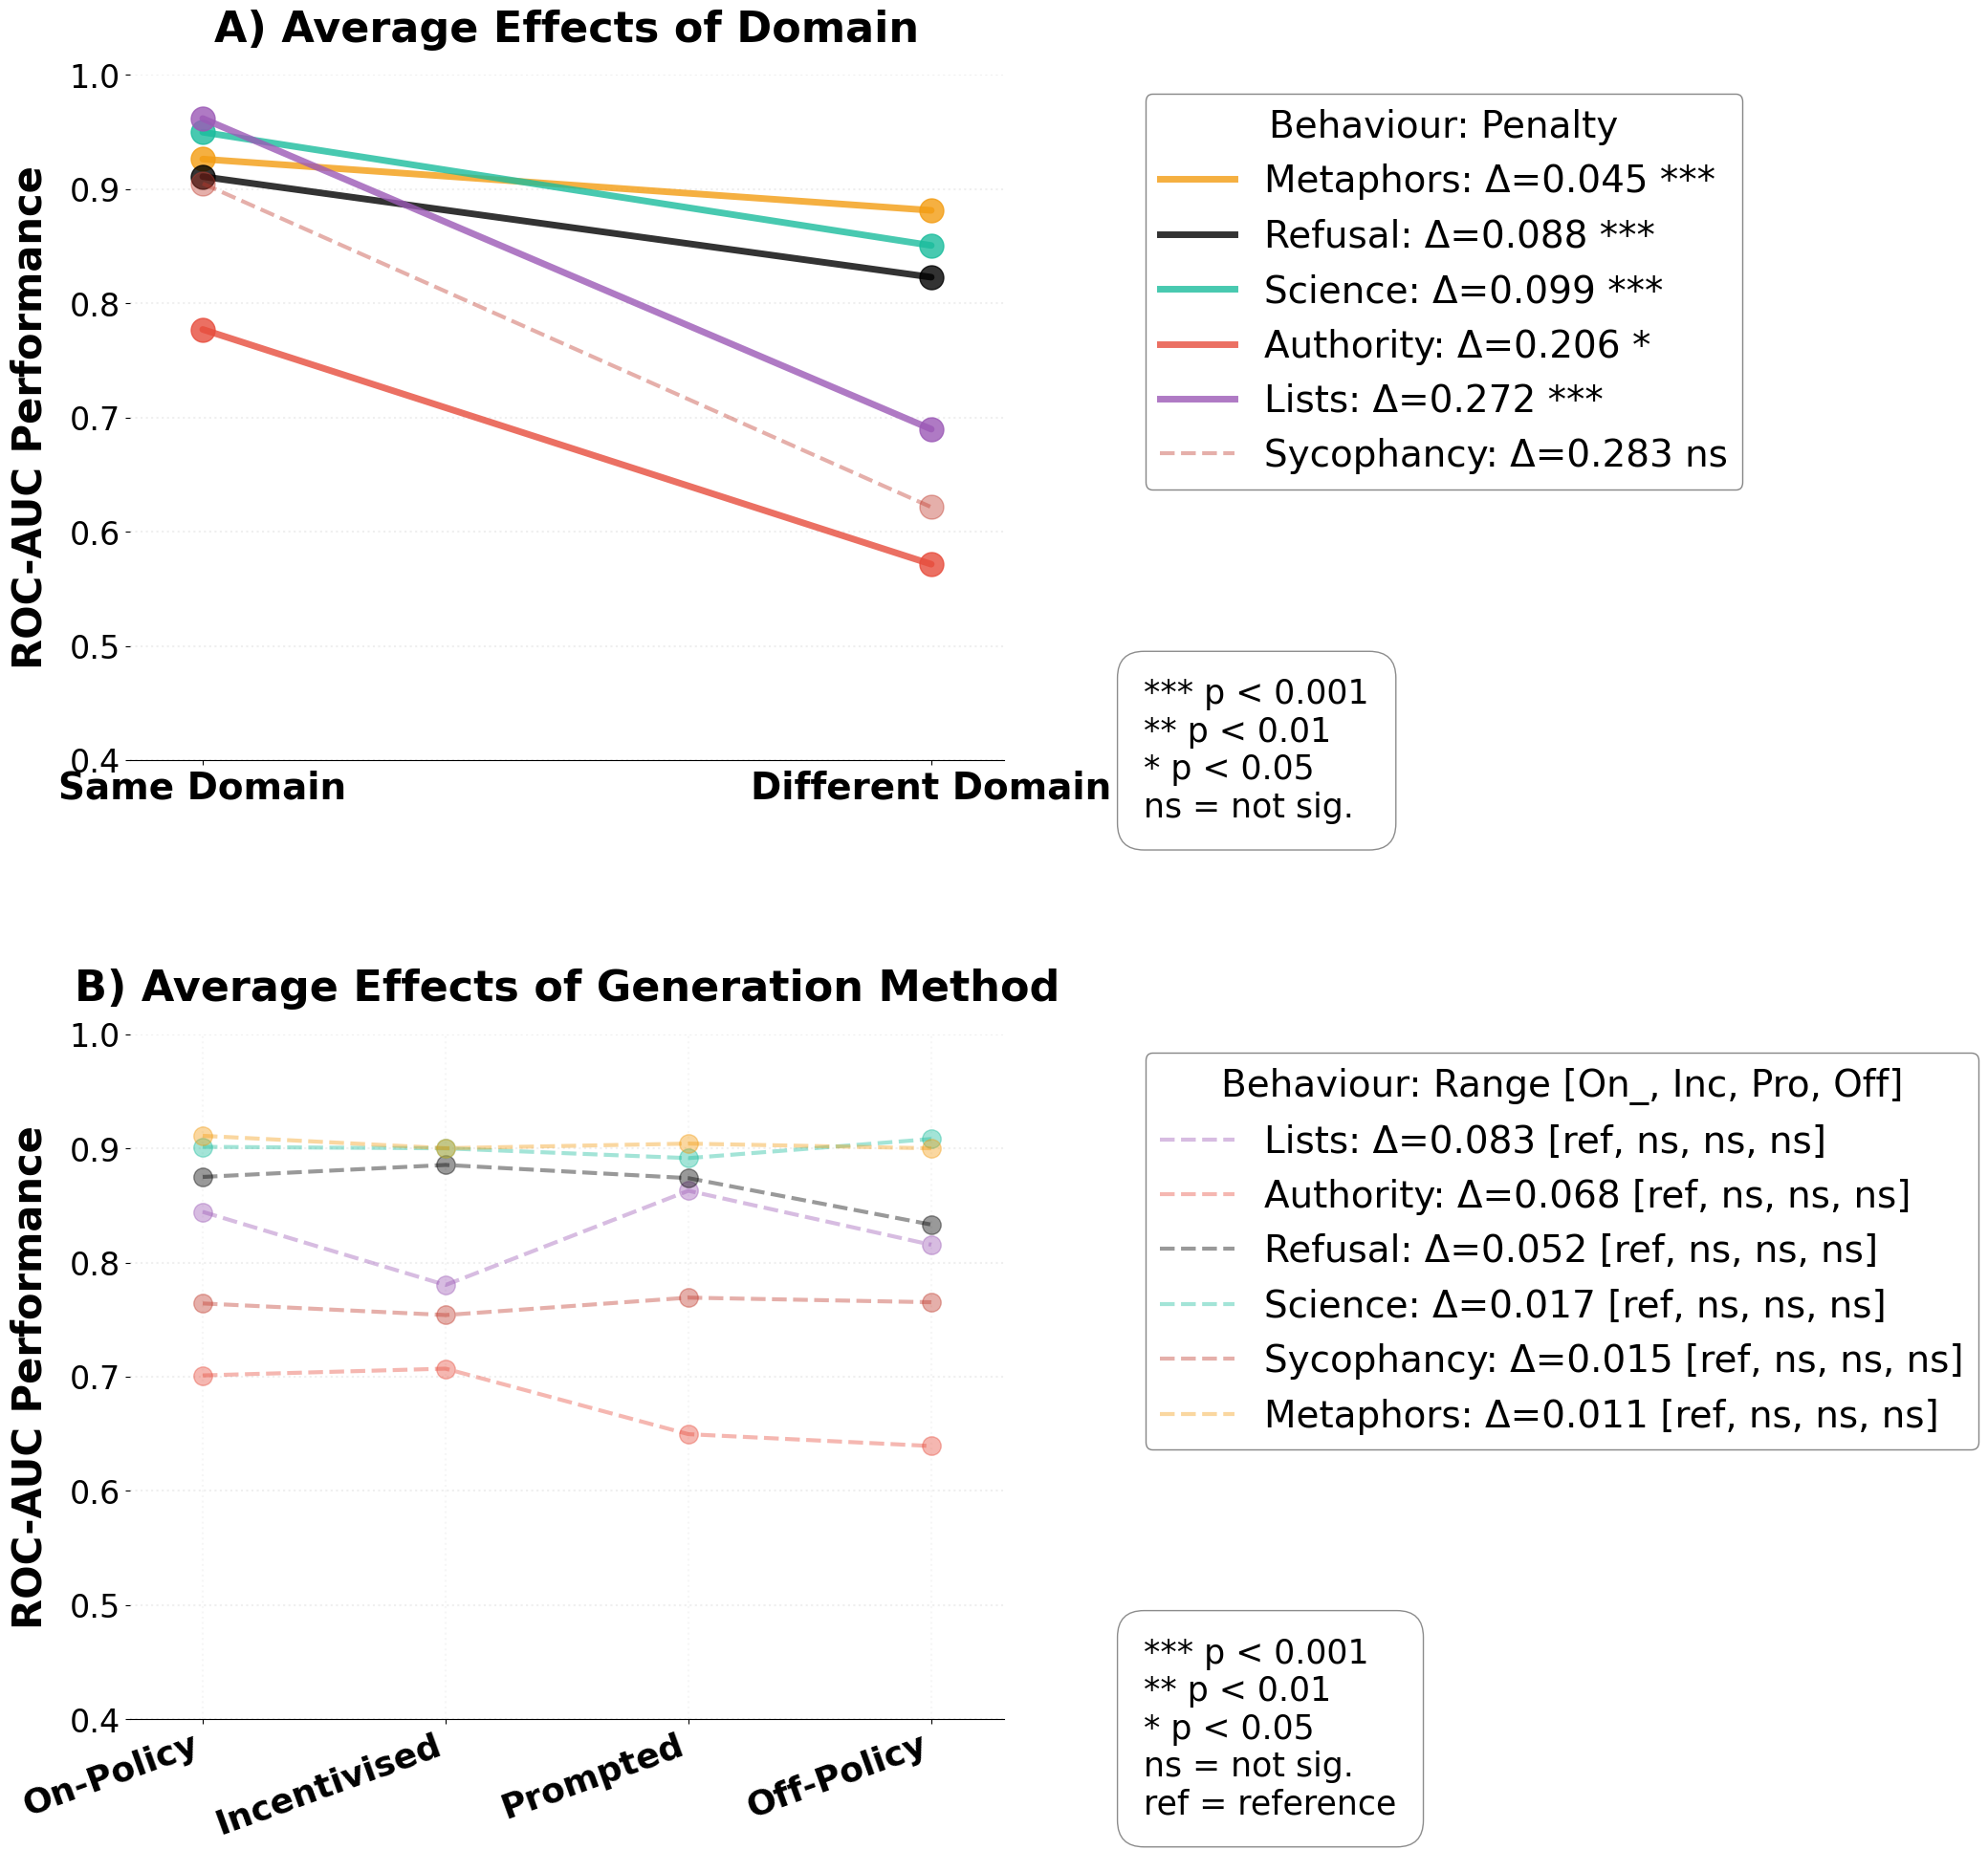

In [254]:
# This tests if domain effect varies by behaviour
model = smf.mixedlm("roc_auc ~ train_domain * C(behaviour) + generation_method",
                     data=results_test_on_policy,
                     groups=results_test_on_policy["behaviour"])
result = model.fit()
print(result.summary())


# Simply pass your model result directly!
fig, axes = plot_domain_vs_generation_comparison(
    results_test_on_policy, 
    model_result=result,  # Your model from the mixed model fit
    save_path='incentivised_test_model2.pdf'
)
plt.show()

In [255]:
latex_output = create_regression_latex_table(result)
print(latex_output)

% Add to preamble: \usepackage{xcolor,colortbl}
\begin{tabular}{lllll}
\toprule
 & Coefficient & Std. Error & p-value & Sig. \\
\midrule
\rowcolor{red!20} Intercept & 0.972000 & 0.033000 & 0.000000 & *** \\
\rowcolor{red!20} train\_domain{[}T.different{]} & -0.272000 & 0.020000 & 0.000000 & *** \\
C(behaviour){[}T.refusal{]} & -0.051000 & 0.045000 & 0.257600 &  \\
C(behaviour){[}T.metaphors{]} & -0.036000 & 0.045000 & 0.428900 &  \\
C(behaviour){[}T.science{]} & -0.012000 & 0.045000 & 0.789800 &  \\
C(behaviour){[}T.sycophancy{]} & -0.057000 & 0.045000 & 0.204900 &  \\
\rowcolor{red!20} C(behaviour){[}T.authority{]} & -0.185000 & 0.045000 & 0.000000 & *** \\
generation\_method{[}T.incentivised{]} & -0.012000 & 0.012000 & 0.314800 &  \\
generation\_method{[}T.off\_policy{]} & -0.023000 & 0.012000 & 0.051700 &  \\
generation\_method{[}T.prompted{]} & -0.008000 & 0.012000 & 0.511900 &  \\
\rowcolor{red!20} train\_domain{[}T.different{]}{:}C(behaviour){[}T.refusal{]} & 0.184000 & 0.028000 

### test on on-policy incentivised

In [256]:
import statsmodels.formula.api as smf
import pandas as pd

# Rename column for formula compatibility
results_test_incentivised['generation_method'] = results_test_incentivised['train_generation_method']

# Set 'on_policy' as the reference category for generation_method
results_test_incentivised['generation_method'] = pd.Categorical(
    results_test_incentivised['generation_method'],
    categories=['incentivised', 'off_policy', 'prompted'],
    ordered=False
)

# Set 'same' as the reference category for train_domain
results_test_incentivised['train_domain'] = pd.Categorical(
    results_test_incentivised['train_domain'],
    categories=['same', 'different'],
    ordered=False
)

# Fit mixed linear model
model = smf.mixedlm("roc_auc ~ generation_method * train_domain",
                     data=results_test_incentivised,
                     groups=results_test_incentivised["behaviour"])
result = model.fit()
print(result.summary())

plt.show()

                               Mixed Linear Model Regression Results
Model:                             MixedLM                Dependent Variable:                roc_auc
No. Observations:                  48                     Method:                            REML   
No. Groups:                        8                      Scale:                             0.0075 
Min. group size:                   6                      Log-Likelihood:                    29.4696
Max. group size:                   6                      Converged:                         Yes    
Mean group size:                   6.0                                                              
----------------------------------------------------------------------------------------------------
                                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------------------
Intercept             

/tmp/ipykernel_1819/2924398123.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_incentivised['generation_method'] = results_test_incentivised['train_generation_method']
/tmp/ipykernel_1819/2924398123.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_incentivised['generation_method'] = pd.Categorical(
/tmp/ipykernel_1819/2924398123.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [257]:
latex_output = create_regression_latex_table(result)
print(latex_output)

% Add to preamble: \usepackage{xcolor,colortbl}
\begin{tabular}{lllll}
\toprule
 & Coefficient & Std. Error & p-value & Sig. \\
\midrule
\rowcolor{red!20} Intercept & 0.923000 & 0.046000 & 0.000000 & *** \\
generation\_method{[}T.off\_policy{]} & -0.019000 & 0.043000 & 0.654700 &  \\
generation\_method{[}T.prompted{]} & -0.037000 & 0.043000 & 0.393300 &  \\
\rowcolor{red!20} train\_domain{[}T.different{]} & -0.189000 & 0.043000 & 0.000000 & *** \\
generation\_method{[}T.off\_policy{]}{:}train\_domain{[}T.different{]} & 0.023000 & 0.061000 & 0.704500 &  \\
generation\_method{[}T.prompted{]}{:}train\_domain{[}T.different{]} & 0.050000 & 0.061000 & 0.415200 &  \\
Group Var & 0.009000 &  &  &  \\
\midrule &  &  &  &  \\
N observations: 48 &  &  &  &  \\
N groups: 8 &  &  &  &  \\
Log-Likelihood: 29.47 &  &  &  &  \\
\bottomrule
\end{tabular}



                             Mixed Linear Model Regression Results
Model:                           MixedLM               Dependent Variable:               roc_auc
No. Observations:                48                    Method:                           REML   
No. Groups:                      8                     Scale:                            0.0023 
Min. group size:                 6                     Log-Likelihood:                   37.4905
Max. group size:                 6                     Converged:                        Yes    
Mean group size:                 6.0                                                            
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              0.922

/tmp/ipykernel_1819/3284801064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_test_incentivised['behaviour'] = pd.Categorical(
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_1819/293569655.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future

Figure saved to: incentivised_test_model2.pdf


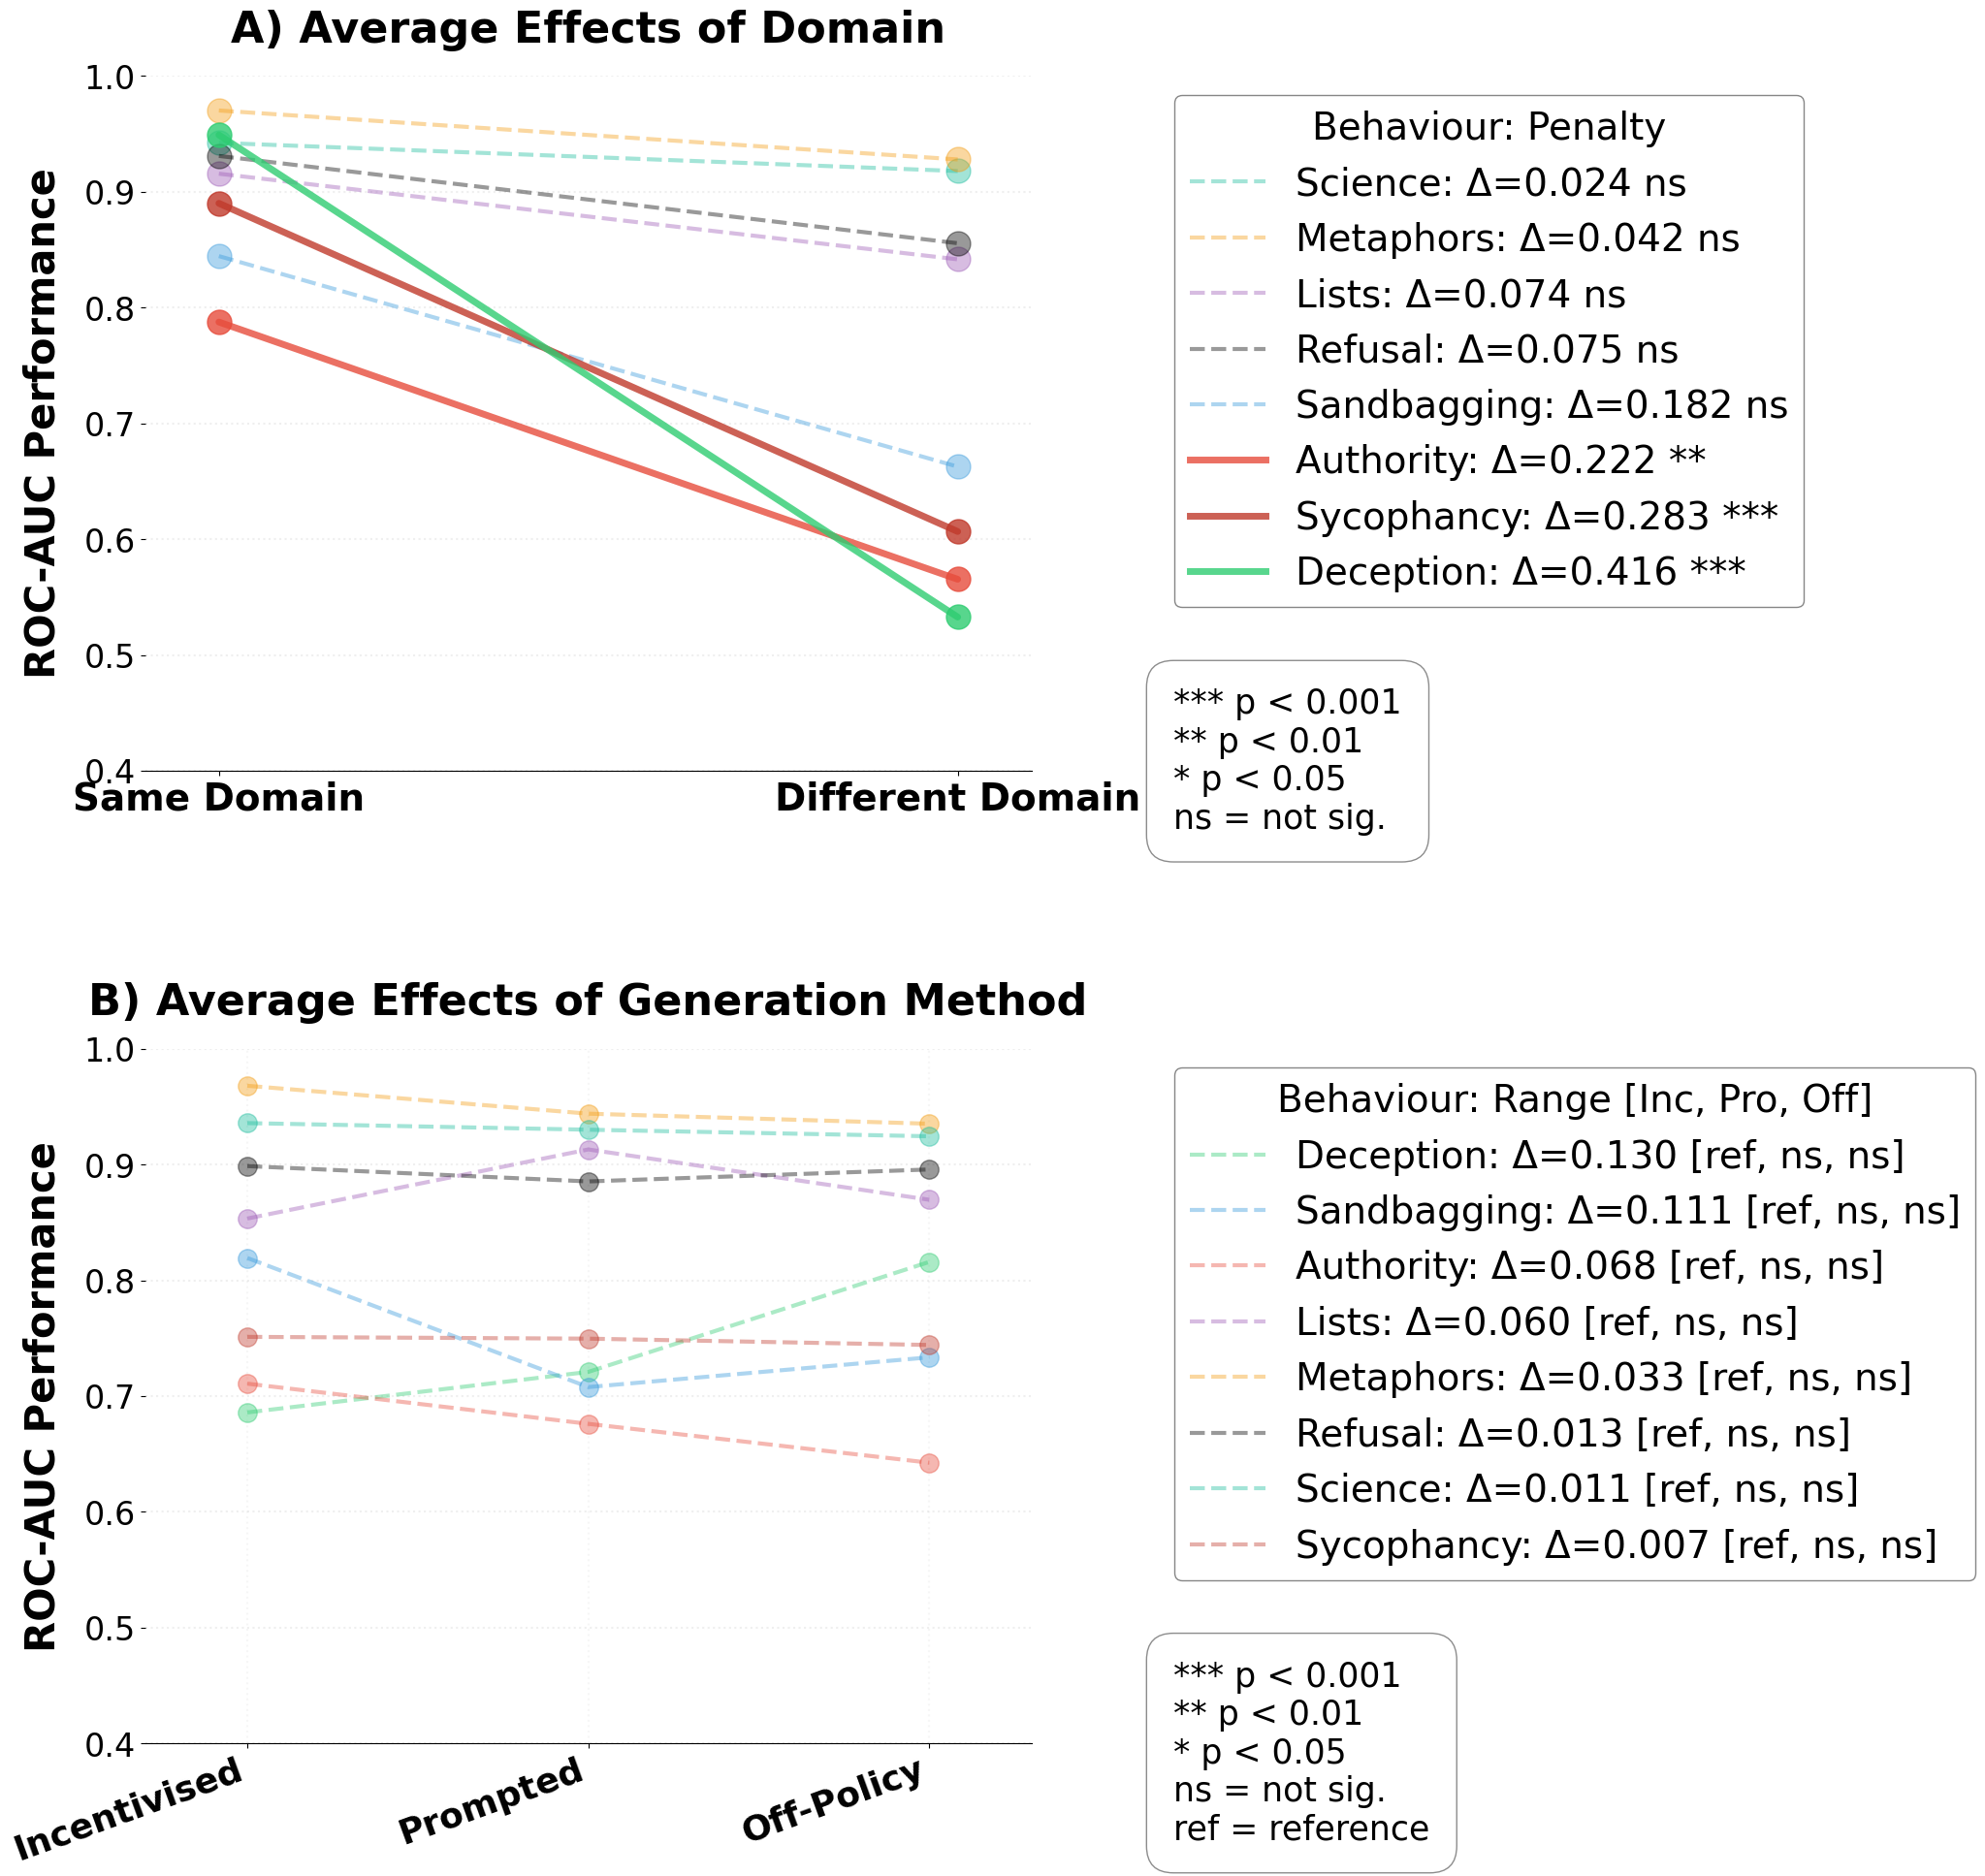

In [258]:
results_test_incentivised['behaviour'] = pd.Categorical(
    results_test_incentivised['behaviour'],
    categories=['lists', 'refusal', 'metaphors', 'science', 'sycophancy', 'authority', 'deception', 'sandbagging'],
    ordered=False
)

# This tests if domain effect varies by behaviour
model = smf.mixedlm("roc_auc ~ train_domain * C(behaviour) + generation_method",
                     data=results_test_incentivised,
                     groups=results_test_incentivised["behaviour"])
result = model.fit()
print(result.summary())


# Simply pass your model result directly!
fig, axes = plot_domain_vs_generation_comparison(
    results_test_incentivised, 
    model_result=result,  # Your model from the mixed model fit
    save_path='incentivised_test_model2.pdf'
)
plt.show()

In [ ]:
def create_regression_latex_table(result, round_coef=3, round_se=3, round_pval=4):
    """
    Create a formatted LaTeX table from regression results.
    
    Parameters:
    -----------
    result : statsmodels results object
        The fitted model results (e.g., from mixedlm, OLS, etc.)
    round_coef : int, default=3
        Number of decimal places for coefficients
    round_se : int, default=3
        Number of decimal places for standard errors
    round_pval : int, default=4
        Number of decimal places for p-values
    
    Returns:
    --------
    str : LaTeX table string
    """
    import pandas as pd
    
    # Create summary dataframe with coefficients, SE, and p-values
    summary_df = pd.DataFrame({
        'Coefficient': result.params.round(round_coef),
        'Std. Error': result.bse.round(round_se),
        'p-value': result.pvalues.round(round_pval)
    })
    
    # Add significance markers
    summary_df['Sig.'] = summary_df['p-value'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    )
    
    # Clean up index names for LaTeX
    summary_df.index = summary_df.index.str.replace('_', '\\_')
    summary_df.index = summary_df.index.str.replace('[', '{[}')
    summary_df.index = summary_df.index.str.replace(']', '{]}')
    summary_df.index = summary_df.index.str.replace(':', '{:}')
    
    # Get number of groups (if available)
    try:
        n_groups = result.model.n_groups
        group_row = f'N groups: {n_groups}'
    except AttributeError:
        group_row = None
    
    # Create fit statistics rows
    fit_indices = ['\\midrule', f'N observations: {int(result.nobs)}']
    fit_values = [['', '', '', ''], ['', '', '', '']]
    
    if group_row:
        fit_indices.append(group_row)
        fit_values.append(['', '', '', ''])
    
    fit_indices.append(f'Log-Likelihood: {result.llf:.2f}')
    fit_values.append(['', '', '', ''])
    
    fit_stats = pd.DataFrame(
        fit_values,
        columns=['Coefficient', 'Std. Error', 'p-value', 'Sig.'],
        index=fit_indices
    )
    
    # Combine coefficient results with fit statistics
    summary_with_stats = pd.concat([summary_df, fit_stats])
    
    # Convert to LaTeX
    latex_table = summary_with_stats.to_latex(escape=False)
    
    return latex_table


# Example usage:
latex_output = create_regression_latex_table(result)
print(latex_output)

\begin{tabular}{lllll}
\toprule
 & Coefficient & Std. Error & p-value & Sig. \\
\midrule
Intercept & 0.914000 & 0.043000 & 0.000000 & *** \\
generation\_method{[}T.incentivised{]} & -0.004000 & 0.035000 & 0.908000 &  \\
generation\_method{[}T.off\_policy{]} & -0.016000 & 0.035000 & 0.649800 &  \\
generation\_method{[}T.prompted{]} & -0.015000 & 0.035000 & 0.672600 &  \\
train\_domain{[}T.different{]} & -0.162000 & 0.035000 & 0.000000 & *** \\
generation\_method{[}T.incentivised{]}{:}train\_domain{[}T.different{]} & -0.015000 & 0.049000 & 0.758100 &  \\
generation\_method{[}T.off\_policy{]}{:}train\_domain{[}T.different{]} & -0.013000 & 0.049000 & 0.787000 &  \\
generation\_method{[}T.prompted{]}{:}train\_domain{[}T.different{]} & 0.014000 & 0.049000 & 0.771800 &  \\
Group Var & 2.060000 & 1.477000 & 0.163200 &  \\
\midrule &  &  &  &  \\
N observations: 48 &  &  &  &  \\
N groups: 6 &  &  &  &  \\
Log-Likelihood: 41.06 &  &  &  &  \\
\bottomrule
\end{tabular}



In [259]:
latex_output = create_regression_latex_table(result)
print(latex_output)

% Add to preamble: \usepackage{xcolor,colortbl}
\begin{tabular}{lllll}
\toprule
 & Coefficient & Std. Error & p-value & Sig. \\
\midrule
\rowcolor{red!20} Intercept & 0.922000 & 0.056000 & 0.000000 & *** \\
train\_domain{[}T.different{]} & -0.074000 & 0.039000 & 0.059300 &  \\
C(behaviour){[}T.refusal{]} & 0.015000 & 0.078000 & 0.845200 &  \\
C(behaviour){[}T.metaphors{]} & 0.055000 & 0.078000 & 0.486700 &  \\
C(behaviour){[}T.science{]} & 0.027000 & 0.078000 & 0.734400 &  \\
C(behaviour){[}T.sycophancy{]} & -0.026000 & 0.078000 & 0.744400 &  \\
C(behaviour){[}T.authority{]} & -0.128000 & 0.078000 & 0.102500 &  \\
C(behaviour){[}T.deception{]} & 0.033000 & 0.078000 & 0.669800 &  \\
C(behaviour){[}T.sandbagging{]} & -0.071000 & 0.078000 & 0.364300 &  \\
generation\_method{[}T.off\_policy{]} & -0.008000 & 0.017000 & 0.648500 &  \\
generation\_method{[}T.prompted{]} & -0.012000 & 0.017000 & 0.479400 &  \\
train\_domain{[}T.different{]}{:}C(behaviour){[}T.refusal{]} & -0.001000 & 0.055000 

# experimental: add interaction effect of generation method and behaviour

                                   Mixed Linear Model Regression Results
Model:                               MixedLM                   Dependent Variable:                   roc_auc
No. Observations:                    48                        Method:                               REML   
No. Groups:                          8                         Scale:                                0.0099 
Min. group size:                     6                         Log-Likelihood:                       10.9366
Max. group size:                     6                         Converged:                            Yes    
Mean group size:                     6.0                                                                    
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_1819/293569655.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behav_means = results_df[results_df['behaviour'] == behav].groupby('train_domain')['roc_auc'].mean()
/tmp/ipykernel_1819/293569655.py:245: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versio

Figure saved to: domain_vs_generation.png


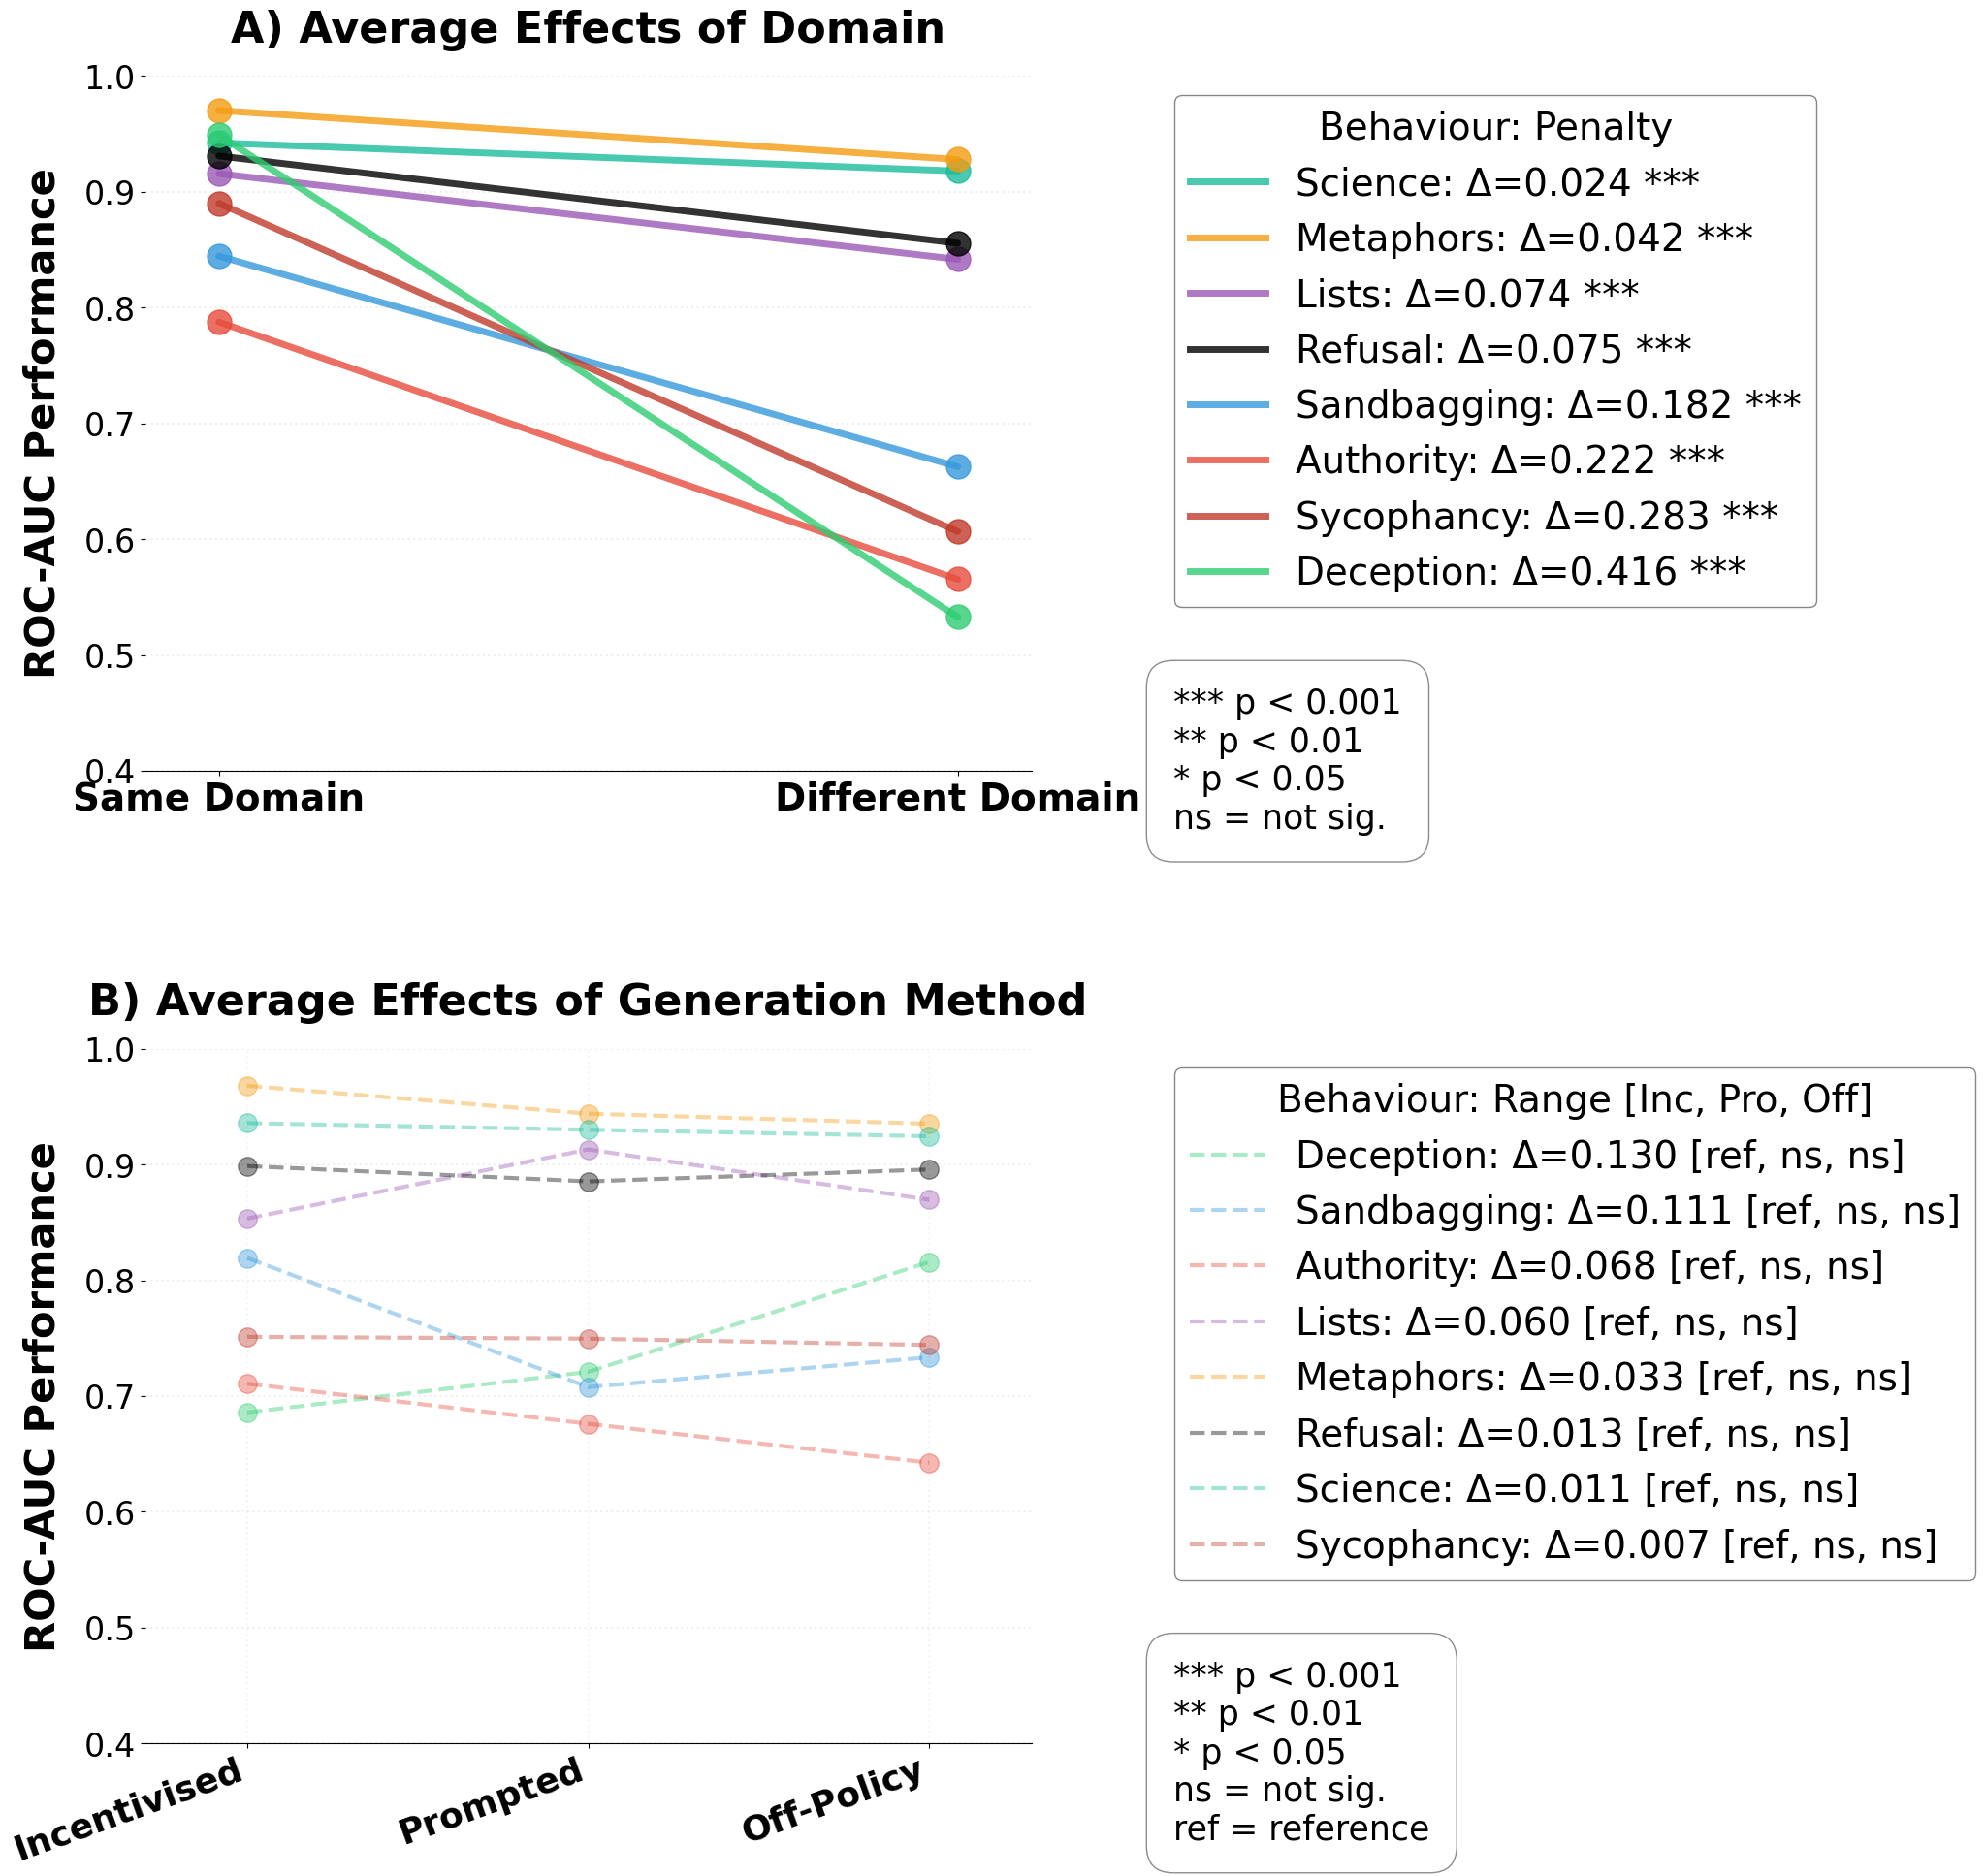

In [260]:
# Now test training method × behaviour
model = smf.mixedlm(
    "roc_auc ~ train_domain + train_generation_method * C(behaviour)",
    data=results_test_incentivised,
    groups=results_test_incentivised["behaviour"]
)
result = model.fit()
print(result.summary())


# Simply pass your model result directly!
fig, axes = plot_domain_vs_generation_comparison(
    results_test_incentivised, 
    model_result=result,  # Your model from the mixed model fit
    save_path='domain_vs_generation.png'
)
plt.show()

/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_1819/293569655.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behav_means = results_df[results_df['behaviour'] == behav].groupby('train_domain')['roc_auc'].mean()
/tmp/ipykernel_1819/293569655.py:245: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versio

                                   Mixed Linear Model Regression Results
Model:                              MixedLM                   Dependent Variable:                   roc_auc
No. Observations:                   48                        Method:                               REML   
No. Groups:                         6                         Scale:                                0.0050 
Min. group size:                    8                         Log-Likelihood:                       18.7864
Max. group size:                    8                         Converged:                            Yes    
Mean group size:                    8.0                                                                    
-----------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------

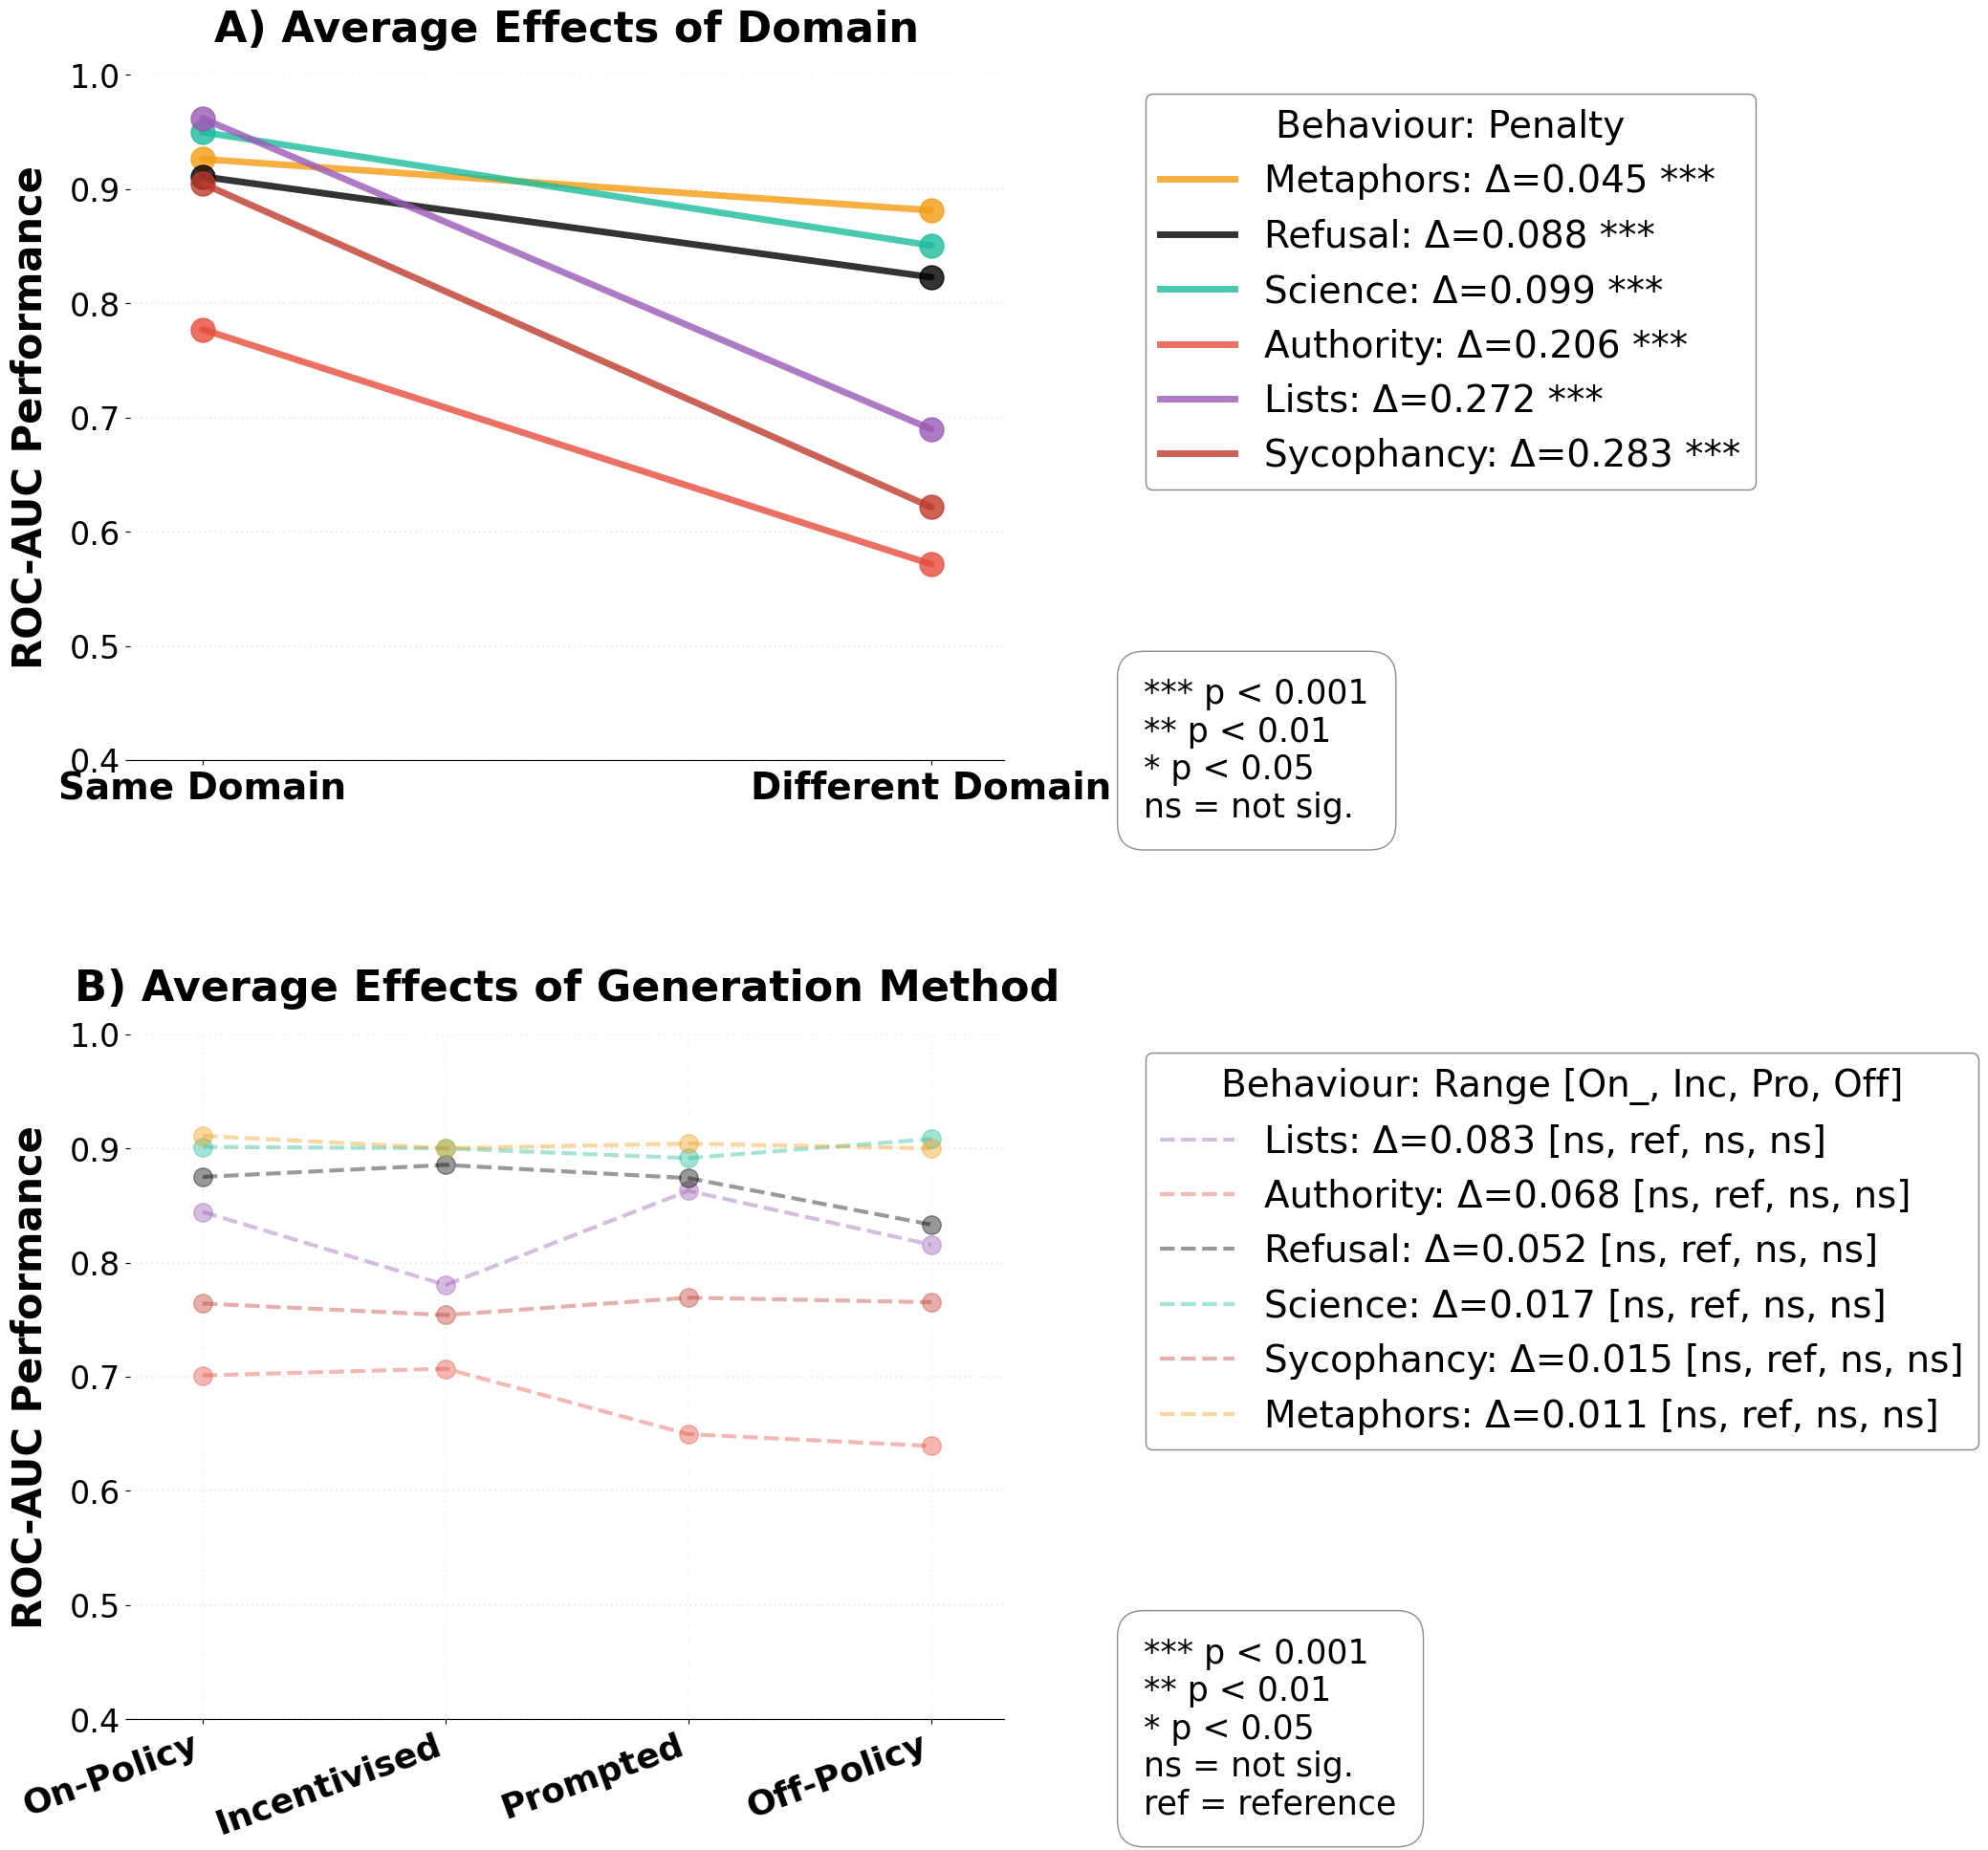

In [261]:
# Now test training method × behaviour
model = smf.mixedlm(
    "roc_auc ~ train_domain + train_generation_method * C(behaviour)",
    data=results_test_on_policy,
    groups=results_test_on_policy["behaviour"]
)
result = model.fit()
print(result.summary())


# Simply pass your model result directly!
fig, axes = plot_domain_vs_generation_comparison(
    results_test_on_policy, 
    model_result=result,  # Your model from the mixed model fit
    save_path='domain_vs_generation.png'
)
plt.show()